# Image Tuning with DimRed API

This notebook demonstrates how to run prompt tuning with image data using the DimRed API.

## Overview

The workflow:
1. Load image dataset from `~/data/image_example.json`
2. Create a project and dataset
3. Add datapoints with image payloads
4. Create a prompt for image classification
5. Create a metric
6. Run tuning
7. Poll for results

## Setup

In [ ]:
import json
import logging
import sys
import os
from pathlib import Path

# Add the parent directory (dimred-examples) to Python path for importing client
# This handles both running from notebooks and via nbconvert
current_dir = os.getcwd()
dimred_root = current_dir

# Find the dimred-examples directory
if 'dimred-examples' in current_dir:
    # Split path and find dimred-examples root
    parts = current_dir.split('/')
    idx = next(i for i, p in enumerate(parts) if 'dimred-examples' in p)
    dimred_root = '/'.join(parts[:idx+1])

if dimred_root not in sys.path:
    sys.path.insert(0, dimred_root)

from client import DimRedAPIClient

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    stream=sys.stdout,
    force=True
)
logger = logging.getLogger(__name__)

## Configuration

In [ ]:
# API Configuration
API_KEY = os.environ.get("DIMRED_API_KEY")
BASE_URL = "https://www.dimred.com"  # Updated URL

# Path to image dataset
current_dir = os.getcwd()
dimred_root = current_dir

# Find the dimred-examples directory
if 'dimred-examples' in current_dir:
    # Split path and find dimred-examples root
    parts = current_dir.split('/')
    idx = next(i for i, p in enumerate(parts) if 'dimred-examples' in p)
    dimred_root = '/'.join(parts[:idx+1])

IMAGE_DATASET_PATH = os.path.join(dimred_root, 'data', 'image_example.json')

# Initialize client
client = DimRedAPIClient(API_KEY, BASE_URL)
print(f"✓ Initialized DimRed API client")
print(f"✓ Dataset path: {IMAGE_DATASET_PATH}")

## Step 1: Load Image Dataset

The dataset contains datapoints with image payloads. Each datapoint has:
- `input_data`: The question/instruction
- `expected_output`: The expected response
- `payloads`: Array of payloads, including images with base64-encoded data

In [3]:
# Load the image dataset
with open(IMAGE_DATASET_PATH, 'r') as f:
    image_dataset = json.load(f)

print(f"Loaded {len(image_dataset)} datapoints from {IMAGE_DATASET_PATH}")
print(f"\nFirst datapoint structure:")
print(f"  - input_data keys: {list(image_dataset[0]['input_data'].keys())}")
print(f"  - expected_output keys: {list(image_dataset[0]['expected_output'].keys())}")
print(f"  - Number of payloads: {len(image_dataset[0]['payloads'])}")
print(f"  - Payload type: {image_dataset[0]['payloads'][0]['payload_type']}")

Loaded 10 datapoints from /Users/jonathanjohannemann/dimred-examples/data/image_example.json

First datapoint structure:
  - input_data keys: ['instruction', 'question']
  - expected_output keys: ['is_cat', 'reasoning']
  - Number of payloads: 1
  - Payload type: image


## Step 2: Create Project

In [4]:
project_id = client.create_project(
    project_name="Image Classification Tuning",
    project_description="Testing image-based prompt tuning with cat detection"
)

print(f"✓ Created project: {project_id}")

[2025-10-27 19:51:40] INFO - Creating project: Image Classification Tuning
[2025-10-27 19:51:40] INFO - ✓ Project created: 29cd0c41-1240-4f96-93f9-8e6101b1f542
✓ Created project: 29cd0c41-1240-4f96-93f9-8e6101b1f542


## Step 3: Create Dataset

In [5]:
dataset_id = client.create_dataset(
    project_id=project_id,
    dataset_name="Cat Detection Image Dataset"
)

print(f"✓ Created dataset: {dataset_id}")

[2025-10-27 19:51:40] INFO - Creating dataset: Cat Detection Image Dataset for project 29cd0c41-1240-4f96-93f9-8e6101b1f542
[2025-10-27 19:51:41] INFO - ✓ Dataset created: ds-57dc565d-ed46-48a5-a423-1bc2aaa637c0
✓ Created dataset: ds-57dc565d-ed46-48a5-a423-1bc2aaa637c0


## Step 4: Add Datapoints with Image Payloads

When adding datapoints with images, the API expects:
- `input_data`: JSON string of the input
- `expected_output`: JSON string of the expected output
- `payloads`: Array of payload objects with structure:
  ```json
  {
    "payload_type": "image",
    "payload": {
      "media_type": "image/png",
      "data": "base64_encoded_image_data"
    }
  }
  ```

[2025-10-27 19:51:41] INFO - Adding 10 datapoints to dataset ds-57dc565d-ed46-48a5-a423-1bc2aaa637c0
[2025-10-27 19:51:43] INFO - ✓ Added 10 datapoints
✓ Added 10 datapoints with image payloads

=== Example Datapoint Structure ===

input_data: {"instruction": "Look at this image and determine if it shows a cat.", "question": "Is this a cat? Answer with true or false."}

expected_output: {"is_cat": true, "reasoning": "This image shows a cat with typical feline features like triangular ears, whiskers, and cat-like body proportions."}

payloads: 1 payload(s)

--- Rendering Image Payload ---
Media type: image/png
Payload type: image



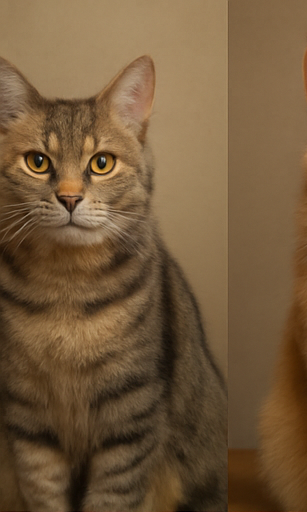

In [6]:
# Convert dataset to API format
datapoints = []
for item in image_dataset:
    datapoint = {
        "input_data": json.dumps(item["input_data"]),
        "expected_output": json.dumps(item["expected_output"]),
        "payloads": item["payloads"]  # Pass payloads as-is
    }
    datapoints.append(datapoint)

# Add to dataset
count = client.add_datapoints(dataset_id, datapoints)
print(f"✓ Added {count} datapoints with image payloads")

# Display an example datapoint structure
print("\n=== Example Datapoint Structure ===")
example = datapoints[0]
print(f"\ninput_data: {example['input_data']}")
print(f"\nexpected_output: {example['expected_output']}")
print(f"\npayloads: {len(example['payloads'])} payload(s)")

# Render the image
from IPython.display import Image, display
import base64

payload = example['payloads'][0]
print(f"\n--- Rendering Image Payload ---")
print(f"Media type: {payload['payload']['media_type']}")
print(f"Payload type: {payload['payload_type']}\n")

# Decode and display the image
image_data = base64.b64decode(payload['payload']['data'])
display(Image(data=image_data))


## Step 5: Create Prompt

Create a prompt for image-based cat detection. The prompt will receive both the text instruction and the image.

In [ ]:
# Create prompt text
prompt_text = (
    "You are a helpful AI assistant.\n\n"
    "Respond with JSON containing:\n"
    "- is_cat: true or false\n"
    "- reasoning: brief explanation of your decision based on visual features"
)

# Output schema for structured response
output_schema = {
    "type": "object",
    "properties": {
        "is_cat": {
            "type": "boolean",
            "description": "Whether the image shows a cat"
        },
        "reasoning": {
            "type": "string",
            "description": "Brief explanation based on visual features"
        }
    },
    "required": ["is_cat", "reasoning"]
}

# Use new API format
prompt_id = client.create_prompt(
    project_id=project_id,
    prompt_text=prompt_text,
    prompt_message_type="system",
    name="Cat Detection from Images",
    output_schema=output_schema
)

print(f"✓ Created prompt: {prompt_id}")

## Step 6: Create Metric

In [8]:
metric_code = '''
import json

def metric_func(output, expected):
    """
    Check if the model correctly identified whether the image shows a cat.
    Returns 1.0 for correct classification, 0.0 for incorrect.
    """
    # Parse output and expected if they're strings
    if isinstance(output, str):
        try:
            output = json.loads(output)
        except json.JSONDecodeError:
            return 0.0

    if isinstance(expected, str):
        try:
            expected = json.loads(expected)
        except json.JSONDecodeError:
            return 0.0

    # Extract is_cat field
    output_value = output.get("is_cat")
    expected_value = expected.get("is_cat")

    # Both must be present and match
    if output_value is None or expected_value is None:
        return 0.0

    # Return 1.0 if they match, 0.0 if they don't
    return 1.0 if output_value == expected_value else 0.0
'''

metric_id = client.create_metric(
    project_id=project_id,
    code=metric_code,
    metric_name="Cat Classification Accuracy",
    metric_description="Measures whether the model correctly identifies cats in images"
)

print(f"✓ Created metric: {metric_id}")

[2025-10-27 19:51:44] INFO - Creating metric for project 29cd0c41-1240-4f96-93f9-8e6101b1f542
[2025-10-27 19:51:44] INFO - ✓ Metric created: 8133fa47-13d0-43ea-8c45-7b812299a92a
✓ Created metric: 8133fa47-13d0-43ea-8c45-7b812299a92a


## Step 7: Run Tuning

Start the prompt tuning session. The model will receive both text instructions and images.

In [ ]:
# Run tuning using the new workflow API
workflow_response = client.run_workflow(
    project_id=project_id,
    dataset_id=dataset_id,
    prompt_id=prompt_id,
    metric_id=metric_id,
    model_name="gpt-4o",  # Use vision-capable model
    provider="openai",
    mode="tune",
    num_iterations=3
)

workflow_id = workflow_response.get("id") or workflow_response.get("tuning_session_id")

print(f"✓ Tuning started")
print(f"  Workflow ID: {workflow_id}")
print(f"  Status: {workflow_response.get('status')}")

## Step 8: Wait for Completion

Poll the tuning session until it completes. This can take 10-30 minutes.

In [ ]:
# Wait for workflow completion using new monitoring
final_result = client.wait_for_workflow_completion(
    workflow_id=workflow_id,
    poll_interval=10,
    timeout=3600
)

print("\n=== Final Results ===")
print(f"Workflow ID: {workflow_id}")
print(f"Status: {final_result.get('status')}")

# Extract metrics data
metrics_data = final_result.get("metrics", {})
final_metrics = metrics_data.get("final_metrics", {})
iteration_results = metrics_data.get("iteration_results", [])

if final_metrics:
    print("\nFinal Metrics:")
    for metric_name, value in final_metrics.items():
        print(f"  {metric_name}: {value}")

if iteration_results:
    print(f"\nCompleted {len(iteration_results)} iterations:")
    for result in iteration_results:
        iter_num = result.get("iteration", "?")
        iter_metrics = result.get("metrics", {})
        print(f"  Iteration {iter_num}: {iter_metrics}")

print(f"\nBest Prompt ID: {metrics_data.get('best_prompt_id', 'N/A')}")
print(f"Final Prompt ID: {metrics_data.get('final_prompt_id', 'N/A')}")

## Step 9: Fetch Best Prompt

In [ ]:
# Fetch the best prompt using the ID from tuning results
best_prompt_id = metrics_data.get('best_prompt_id')

if best_prompt_id:
    print(f"\nFetching best prompt: {best_prompt_id}")
    try:
        best_prompt = client.get_prompt(best_prompt_id)
        
        print("\n=== Best Prompt Details ===")
        print(f"Prompt ID: {best_prompt_id}")
        
        if best_prompt.get('prompt_text'):
            print(f"\nOptimized Prompt Text:")
            print("-" * 50)
            print(best_prompt['prompt_text'])
            print("-" * 50)
        
        if best_prompt.get('output_schema'):
            print(f"\nOutput Schema:")
            print(json.dumps(best_prompt['output_schema'], indent=2))
            
        print("\nNote: This optimized prompt has been tuned for better performance")
        print("with image classification tasks based on your dataset.")
            
    except Exception as e:
        print(f"Note: Could not fetch prompt details: {e}")
        print("The prompt ID can be used to retrieve the prompt later.")
else:
    print("\nNote: Best prompt ID not available in results")

In [ ]:
# Fetch and display the best prompt for image classification
best_prompt_id = metrics_data.get('best_prompt_id')
final_prompt_id = metrics_data.get('final_prompt_id')

print("\n=== Best Image Classification Prompt ===")

if best_prompt_id:
    print(f"Best Prompt ID: {best_prompt_id}")
    
    if final_prompt_id and final_prompt_id != best_prompt_id:
        print(f"Final Prompt ID: {final_prompt_id}")
    
    # Always fetch and display the best prompt
    print(f"\nFetching prompt details for ID: {best_prompt_id}")
    try:
        best_prompt = client.get_prompt(best_prompt_id)
        
        # Check if we got valid prompt data
        if best_prompt and isinstance(best_prompt, dict):
            if best_prompt.get('prompt_text'):
                print("\n✓ Successfully retrieved prompt")
                print(f"\nImage Classification Prompt Text:")
                print("-" * 50)
                print(best_prompt['prompt_text'])
                print("-" * 50)
                
                if best_prompt.get('output_schema'):
                    print(f"\nOutput Schema:")
                    print(json.dumps(best_prompt['output_schema'], indent=2))
                    
                if best_prompt.get('prompt_message_type'):
                    print(f"\nMessage Type: {best_prompt['prompt_message_type']}")
            else:
                # Empty response, fetch the original prompt as fallback
                print(f"API response empty, fetching original prompt ID: {prompt_id}")
                original_prompt = client.get_prompt(prompt_id)
                if original_prompt and original_prompt.get('prompt_text'):
                    print("\n✓ Retrieved original prompt")
                    print(f"\nImage Classification Prompt Text:")
                    print("-" * 50)
                    print(original_prompt['prompt_text'])
                    print("-" * 50)
                else:
                    print("✓ Prompt IDs captured successfully")
        else:
            print("✓ Prompt IDs captured successfully")
            
    except Exception as e:
        print(f"Could not fetch full prompt details: {e}")
        print("✓ Prompt IDs captured successfully")
    
    # Indicate whether optimization occurred
    if prompt_id == best_prompt_id:
        print("\n📊 Result: The original prompt performed best for image classification")
    else:
        print("\n📊 Result: An optimized prompt was generated for better image analysis")
    
    print("\n📝 Use this prompt ID for future image workflows:")
    print(f"   client.run_workflow(..., prompt_id='{best_prompt_id}', ...)")
    
else:
    print("Error: Best prompt ID not available in results")
    print("Check that the tuning workflow completed successfully.")

## Summary

You've successfully completed image-based prompt tuning with the DimRed API:

- ✓ Loaded image dataset with base64-encoded images
- ✓ Created project and dataset
- ✓ Added datapoints with image payloads
- ✓ Created vision prompt
- ✓ Created classification metric
- ✓ Ran tuning with vision-capable model (GPT-4o)
- ✓ Retrieved optimized prompt

## Key Points for Image Payloads

1. **Image Payload Structure**: Images are passed as payloads with `payload_type: "image"` and contain `media_type` and base64 `data`
2. **Model Selection**: Use vision-capable models like `gpt-4o`, `gpt-4-vision-preview`, or `claude-3-opus`
3. **Payload Processing**: The system automatically converts image payloads to the correct format for the LLM provider
4. **Multiple Payloads**: You can have multiple payloads per datapoint (e.g., multiple images or mix of text/images)